# Load packages

In [17]:
import scimap as sm

import sys
import anndata as ad
import seaborn as sns; sns.set(color_codes=True)
import numpy as np

import scanpy as sc
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy import stats

In [27]:
import sys
print(sys.version)

3.10.16 | packaged by conda-forge | (main, Dec  5 2024, 14:12:04) [Clang 18.1.8 ]


In [31]:
import scanpy
print(scanpy.__version__)

1.10.4


# Load data

In [2]:
data = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv', index_col=0)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_67979/1161626377.py:1: DtypeWarning:

Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.



In [3]:
data

,S9.6,HER3,panCK,SMA,CD45,Ki67_2,CD4,FOXP3,CD8a,CD11b,...,antioxidant_TXNRD1,antioxidant_GLUT1,NQO1_GCLC_VIM,celltype_2,celltype_1,Tumor_state,GCLC_VIM,CellCategory,SC45px_neigh_kmeans_10,RCNs
CellID,,,,,,,,,,,,,,,,,,,,,
1,0.587351,0.668424,0.197573,0.119095,0.357855,0.221494,0.351031,0.261670,0.120537,0.641891,...,failed_classify,failed_classify,---,Other,Other.Stroma,Other.Stroma,Other.Stroma,Stroma,4,RCN3
10,0.711467,0.738836,0.522747,0.185507,0.275963,0.214838,0.374685,0.350623,0.029450,0.608733,...,TXNRD1_pos,failed_classify,+--,Tumor_+--,Tumor,Tumor,Tumor.GCLC-VIM-,Tumor,2,RCN1
10,0.803970,0.824031,0.331924,0.204348,0.355699,0.234078,0.518679,0.390894,0.161177,0.666724,...,failed_classify,failed_classify,+--,CD68.Macrophages,CD68.Macrophages,CD68.Macrophages,CD68.Macrophages,Immune,4,RCN3
100,0.744246,0.762114,0.531392,0.185345,0.246533,0.227313,0.392369,0.348677,0.023832,0.619029,...,TXNRD1_pos,failed_classify,+--,Tumor_+--,Tumor,Tumor,Tumor.GCLC-VIM-,Tumor,2,RCN1
100,0.796639,0.796858,0.357244,0.192493,0.431782,0.228827,0.489430,0.380457,0.156145,0.674359,...,failed_classify,failed_classify,---,Immune,Other.Immune,Other.Immune,Other.Immune,Immune,4,RCN3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99998,0.832069,0.723583,0.638020,0.130660,0.135379,0.173406,0.316902,0.220026,0.366662,0.634752,...,failed_classify,failed_classify,---,Tumor_---,Tumor,Tumor,Tumor.GCLC-VIM-,Tumor,2,RCN1
99999,0.770561,0.929819,0.451729,0.390374,0.620998,0.488494,0.532568,0.522331,0.467017,0.871813,...,failed_classify,failed_classify,-++,FOXP3.CD4.Tregs,Treg,Treg,Treg,Immune,1,RCN2
99999,0.678946,0.721054,0.228812,0.598502,0.598347,0.229858,0.528080,0.499220,0.232839,0.704152,...,failed_classify,failed_classify,-++,CD4.T.cells,CD4.T.cells,CD4.T.cells,CD4.T.cells,Immune,1,RCN2


In [4]:
image_path = '/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv'
# Convert the data to scimap format
adata = sm.pp.mcmicro_to_scimap(image_path, 
                                remove_dna=False, remove_string_from_name=None, log=False, drop_markers=None,
                                random_sample=None, unique_CellId=True, CellId='CellID', split='X_centroid',
                                custom_imageid=None, min_cells=None, output_dir=None)
adata.obsm['spatial'] = np.array(adata.obs[['Y_centroid', 'X_centroid']])
adata

Loading Data_AllMarkers_filtered_RCNs.csv


/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/scimap/preprocessing/mcmicro_to_scimap.py:106: DtypeWarning:

Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.



AnnData object with n_obs × n_vars = 3681772 × 25
    obs: 'X_centroid', 'Y_centroid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage', 'patient_id_AB19_1654', 'Area', 'Eccentricity', 'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1', 'NQO1_GCLC_VIM', 'celltype_2', 'celltype_1', 'Tumor_state', 'GCLC_VIM', 'CellCategory', 'SC45px_neigh_kmeans_10', 'RCNs', 'CellID', 'imageid'
    uns: 'all_markers'
    obsm: 'spatial'

# Celltype proportion

## Waterfall plot by patients

In [9]:
data['patient_id_AB19_1654'].nunique()

186

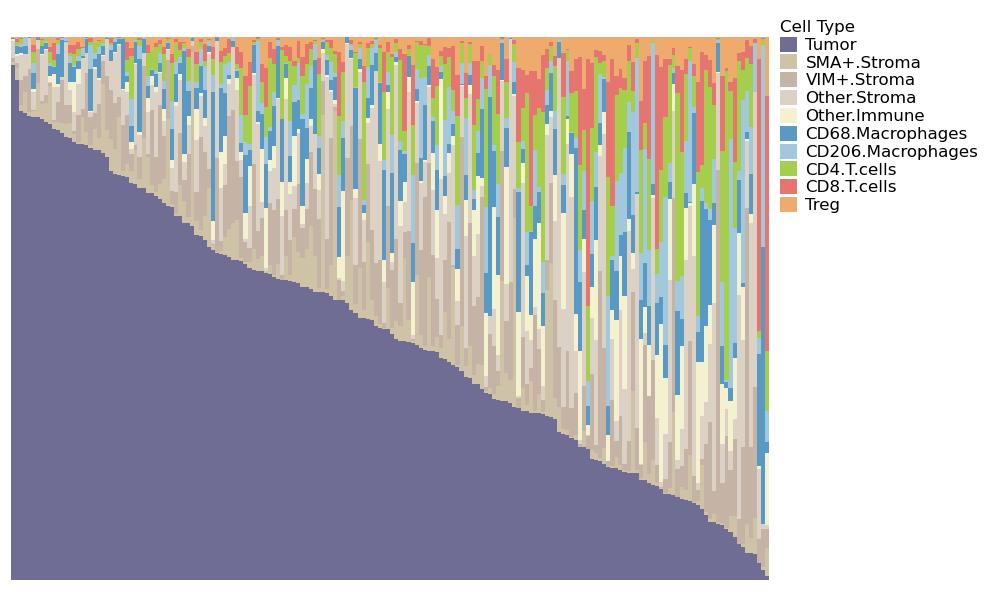

In [10]:
df = data[['patient_id_AB19_1654', 'celltype_1']]

# Group the data by patient ID and celltype columns
count_df = df.groupby(['patient_id_AB19_1654', 'celltype_1']).size().unstack(fill_value=0)

# Get the total counts of each patient
total_counts = df['patient_id_AB19_1654'].value_counts().sort_index()
# Calculate the percentage of each cell type in each patient
percent_df = count_df.div(total_counts, axis=0) * 100

# Create a custom order based on cell types
custom_order = ['Tumor', 'SMA+.Stroma', 'VIM+.Stroma', 'Other.Stroma', 'Other.Immune', 
                'CD68.Macrophages', 'CD206.Macrophages', 'CD4.T.cells', 'CD8.T.cells', 'Treg'
                ]
# Reorder the columns according to the custom_order
percent_df = percent_df.reindex(columns=custom_order)

# Sort by Tumor ratio from high to low
sorted_samples = percent_df.sort_values(by='Tumor', ascending=False).index.tolist()
# Sort the data
sorted_data = percent_df.loc[sorted_samples, custom_order]

# Define colors for each cell type
colors_dict = {
    'SMA+.Stroma': '#cec3a7',
    'VIM+.Stroma': '#c5b3a5',
    'Other.Stroma': '#dbd1c5',
    'Tumor': '#706d94',
    'CD206.Macrophages': '#A2C8DD', 
    'CD68.Macrophages': '#589AC4',
    'CD4.T.cells': '#A5CE4D',   
    'CD8.T.cells': '#E6756F',    
    'Treg': '#EFAB6D',   
    'Other.Immune': '#f4f1d0',    
}

# Set the style
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
sorted_data.plot(kind='bar', stacked=True, color=[colors_dict.get(x) for x in sorted_data.columns], 
                ax=ax, width=1.05, edgecolor='none')


# Add the legend outside the plot
legend = plt.legend(title='Cell Type', bbox_to_anchor=(1.0, 1), 
           loc='upper left', fontsize=12,
           frameon=False,
           handleheight=1.0, handlelength=1.0,
           handletextpad=0.5, labelspacing=0.1,
           borderpad=0.1)
legend.get_title().set_fontsize(12)  # Increase title font size
legend._legend_box.align = "left"

for spine in ax.spines.values():
    spine.set_visible(False)
plt.yticks([])
plt.xticks([]) 

# Add labels and title
plt.title('', fontsize=12)
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save as PDF
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/cell_types_by_patients_dpi300.pdf', bbox_inches='tight', dpi=300)
plt.show()


## By clusters

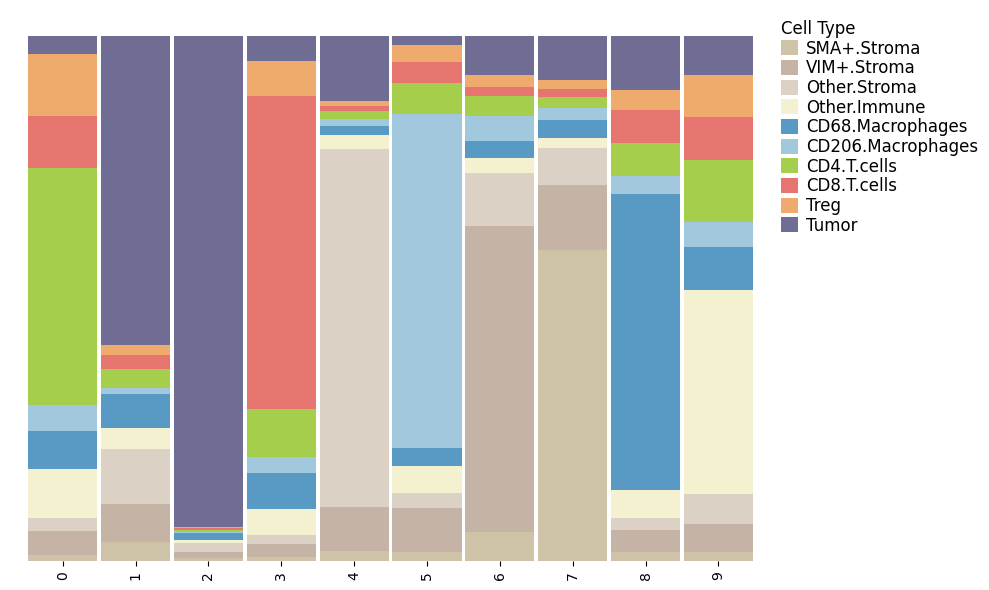

In [39]:

df = data[['SC45px_neigh_kmeans_10', 'celltype_1']]

# Group the data by RCNs and celltype columns
count_df = df.groupby(['SC45px_neigh_kmeans_10', 'celltype_1']).size().unstack(fill_value=0)

# Get the total counts of each RPD
total_counts = df['SC45px_neigh_kmeans_10'].value_counts().sort_index()
# Calculate the percentage of each cell type in each RPD
percent_df = count_df.div(total_counts, axis=0) * 100

# Create a custom order based on cell types
#custom_order = ['SMA+.Stroma', 'VIM+.Stroma', 'Other.Stroma', 
#                'CD68.Macrophages', 'CD206.Macrophages', 'CD4.T.cells', 'CD8.T.cells', 'Treg', 'Other.Immune', 
#                'Tumor']
custom_order = ['SMA+.Stroma', 'VIM+.Stroma', 'Other.Stroma', 
                'Other.Immune', 'CD68.Macrophages', 'CD206.Macrophages', 'CD4.T.cells', 'CD8.T.cells', 'Treg', 
                'Tumor']

# Reorder the columns according to the custom_order
percent_df = percent_df.reindex(columns=custom_order)

# Define colors for each cell type
colors_dict = {
    'SMA+.Stroma': '#cec3a7',
    'VIM+.Stroma': '#c5b3a5',
    'Other.Stroma': '#dbd1c5',
    'Tumor': '#706d94',
    'CD206.Macrophages': '#A2C8DD', 
    'CD68.Macrophages': '#589AC4',
    'CD4.T.cells': '#A5CE4D',   
    'CD8.T.cells': '#E6756F',    
    'Treg': '#EFAB6D',   
    'Other.Immune': '#f4f1d0',    
}

# Set the style
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'


# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
percent_df.plot(kind='bar', stacked=True, color=[colors_dict.get(x) for x in percent_df.columns], 
                ax=ax, width=0.95, edgecolor='none')

# Add the legend outside the plot
legend = plt.legend(title='Cell Type', bbox_to_anchor=(1.0, 1), 
           loc='upper left', fontsize=12,
           frameon=False,
           handleheight=1.0, handlelength=1.0,
           handletextpad=0.5, labelspacing=0.1,
           borderpad=0.1)
#legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(12)  # Increase title font size
legend._legend_box.align = "left"

for spine in ax.spines.values():
    spine.set_visible(False)
plt.yticks([]) 

# Add labels and title
plt.title('', fontsize=12)
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)
plt.xticks(rotation=90)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save as PDF
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/cell_types_by_clusters.pdf', bbox_inches='tight', dpi=500)
plt.show()

## By RCNs

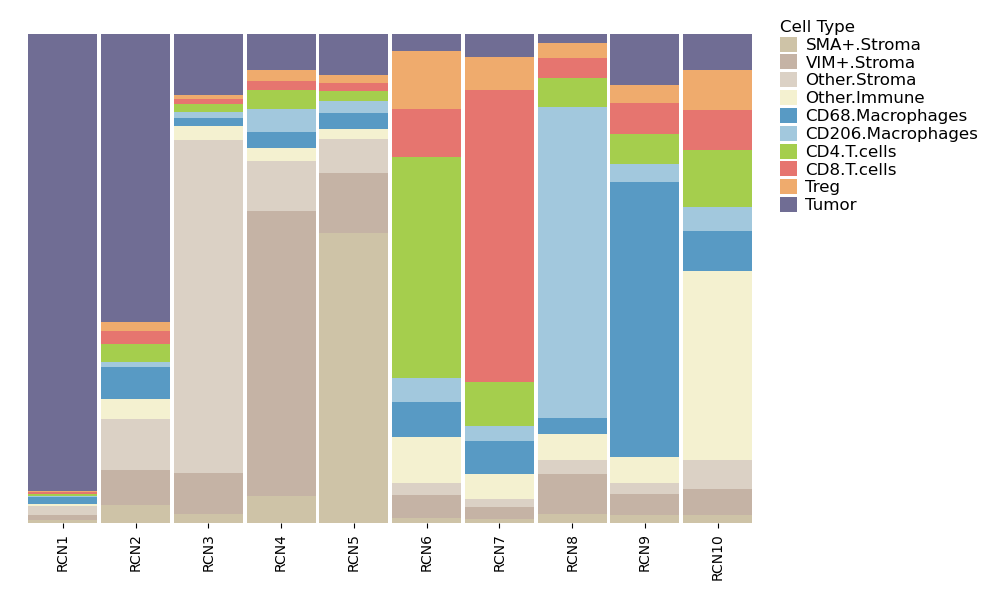

In [16]:

df = data[['RCNs', 'celltype_1']]

# Group the data by RCNs and celltype columns
count_df = df.groupby(['RCNs', 'celltype_1']).size().unstack(fill_value=0)

# Get the total counts of each RPD
total_counts = df['RCNs'].value_counts().sort_index()
# Calculate the percentage of each cell type in each RPD
percent_df = count_df.div(total_counts, axis=0) * 100

# Create a custom order based on cell types
#custom_order = ['SMA+.Stroma', 'VIM+.Stroma', 'Other.Stroma', 
#                'CD68.Macrophages', 'CD206.Macrophages', 'CD4.T.cells', 'CD8.T.cells', 'Treg', 'Other.Immune', 
#                'Tumor']
custom_order = ['SMA+.Stroma', 'VIM+.Stroma', 'Other.Stroma', 
                'Other.Immune', 'CD68.Macrophages', 'CD206.Macrophages', 'CD4.T.cells', 'CD8.T.cells', 'Treg', 
                'Tumor']

# Reorder the columns according to the custom_order
percent_df = percent_df.reindex(columns=custom_order)
# Sort the RCNs numerically
sorted_rcns = sorted(percent_df.index, key=lambda x: int(x[3:]) if x[3:].isdigit() else float('inf'))
percent_df = percent_df.reindex(sorted_rcns)


# Define colors for each cell type
colors_dict = {
    'SMA+.Stroma': '#cec3a7',
    'VIM+.Stroma': '#c5b3a5',
    'Other.Stroma': '#dbd1c5',
    'Tumor': '#706d94',
    'CD206.Macrophages': '#A2C8DD', 
    'CD68.Macrophages': '#589AC4',
    'CD4.T.cells': '#A5CE4D',   
    'CD8.T.cells': '#E6756F',    
    'Treg': '#EFAB6D',   
    'Other.Immune': '#f4f1d0',    
}

# Set the style
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
percent_df.plot(kind='bar', stacked=True, color=[colors_dict.get(x) for x in percent_df.columns], 
                ax=ax, width=0.95, edgecolor='none')

# Add the legend outside the plot
legend = plt.legend(title='Cell Type', bbox_to_anchor=(1.0, 1), 
           loc='upper left', fontsize=12,
           frameon=False,
           handleheight=1.0, handlelength=1.0,
           handletextpad=0.5, labelspacing=0.1,
           borderpad=0.1)
#legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(12)  # Increase title font size
legend._legend_box.align = "left"

for spine in ax.spines.values():
    spine.set_visible(False)
plt.yticks([]) 

# Add labels and title
plt.title('', fontsize=12)
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)
plt.xticks(rotation=90)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout to prevent label cutoff
plt.tight_layout()


mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
# Save as PDF
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/cell_types_by_RCNs_2.pdf', bbox_inches='tight')
plt.show()

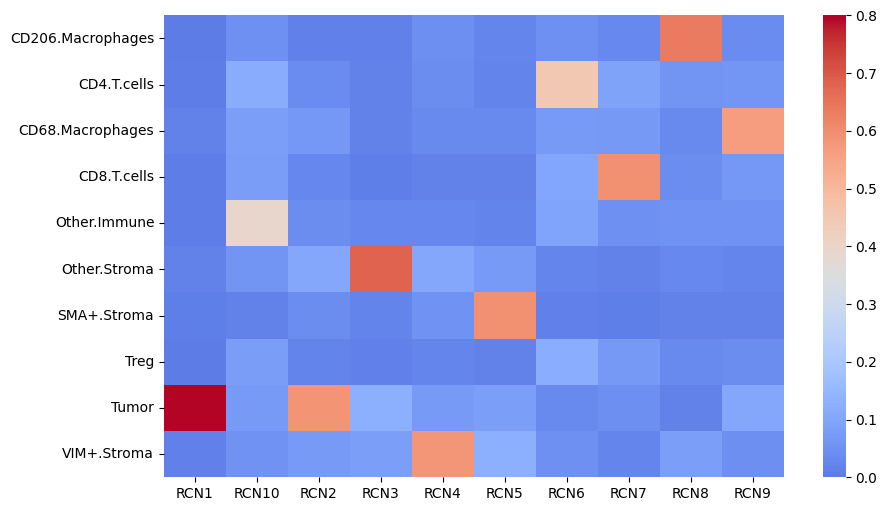

In [26]:
df = data[['RCNs', 'celltype_1']]

pivot_df = df.pivot_table(index='celltype_1', columns='RCNs', aggfunc=len, fill_value=0)

proportion_df = pivot_df.div(pivot_df.sum(axis=0), axis=1)

plt.figure(figsize=(10, 6))
sns.heatmap(proportion_df, cmap='coolwarm',
            annot=False, fmt='d', annot_kws={'size': 8},
            vmin=0, vmax=0.8, center=0.35
            #linewidths=0.5, linecolor='black'
            )
plt.title('', fontsize=12)
plt.xlabel('', fontsize=10)
plt.ylabel('', fontsize=10)

# Save as PDF
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/cell_types_by_RCNs_heatmap.pdf', bbox_inches='tight', dpi=500)
plt.show()

## Total counts

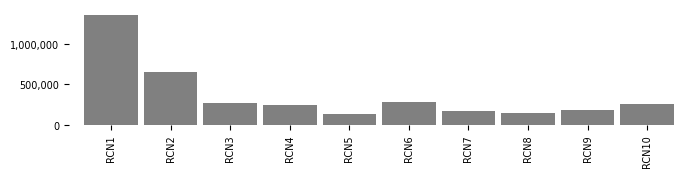

In [25]:
# Plot the stacked bar plot
# Reorder total_counts to match the order of percent_df
total_counts_reordered = total_counts.reindex(percent_df.index)

ax = total_counts_reordered.plot(kind='bar', stacked=False, figsize=(8, 1.5),
                                 color='gray', width=0.9, edgecolor='none')
for spine in ax.spines.values():
    spine.set_visible(False)

#plt.xticks([])
#plt.yticks([])  
xlim = ax.get_xlim()
ax.set_xlim(xlim[0] - 0.01, xlim[1])

# Add the total counts to the plot
#for i, total in enumerate(total_counts_reordered):
#    ax.text(i, total + 50, f"{total:,}", ha='center', va='bottom', fontsize=7)

# Add labels and title
plt.title('', fontsize=8)
plt.ylabel('', fontsize=8)
plt.xlabel('', fontsize=8)
plt.xticks(rotation=90,fontsize=7)
plt.yticks(fontsize=7)

# Disable scientific notation on y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Save as PDF
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/total_counts_by_RCNs_dpi200.pdf', bbox_inches='tight', dpi=200)
plt.show()

# Antiox markers expression by RCNs

## All cells

In [6]:
data['celltype_1'].unique()

array(['Other.Stroma', 'Tumor', 'CD68.Macrophages', 'Other.Immune',
       'Treg', 'CD4.T.cells', 'SMA+.Stroma', 'CD206.Macrophages',
       'VIM+.Stroma', 'CD8.T.cells'], dtype=object)

In [5]:
df

,GCLC,NQO1,TXNRD1
Other.Stroma,0.379279,0.341701,0.336296
Tumor,0.430356,0.428989,0.396635
CD68.Macrophages,0.525653,0.374883,0.401626
Other.Immune,0.483733,0.380518,0.397731
Treg,0.518377,0.361434,0.411430
CD4.T.cells,0.532900,0.381617,0.422781
SMA+.Stroma,0.507133,0.299141,0.355221
CD206.Macrophages,0.536208,0.326160,0.399383
VIM+.Stroma,0.523380,0.342156,0.368812
CD8.T.cells,0.513478,0.379426,0.414662


/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning:

``square=True`` ignored in clustermap



<Figure size 400x300 with 0 Axes>

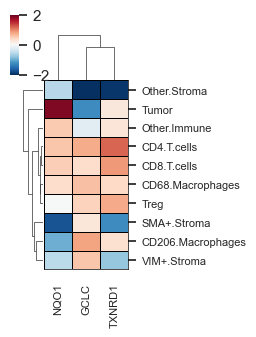

In [4]:

markers = ['GCLC', 'NQO1', 'TXNRD1']
RCNs = ['Other.Stroma', 'Tumor', 'CD68.Macrophages', 'Other.Immune',
       'Treg', 'CD4.T.cells', 'SMA+.Stroma', 'CD206.Macrophages',
       'VIM+.Stroma', 'CD8.T.cells']


expression_data = []
for RCN in RCNs:
    RCN_data = data[data['celltype_1'] == RCN][markers].mean()
    expression_data.append(RCN_data)

df = pd.DataFrame(expression_data, index=RCNs, columns=markers)

df_zscore = (df - df.mean()) / df.std()


plt.figure(figsize=(4, 3))
g = sns.clustermap(df_zscore, 
                  cmap='RdBu_r', 
                  center=0,   
                  vmin=-2,    
                  vmax=2,         
                  xticklabels=True,
                  yticklabels=True,
                  dendrogram_ratio=0.2,
                  cbar_pos=(0.02, 0.8, 0.03, 0.2),
                  linewidths=0.5,
                  linecolor='black',
                  square=True,
                  figsize=(3, 3)
                 )

for spine in g.ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.5)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='center', fontsize=8)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)


plt.suptitle('', y=1.02)

# Save as PDF
#plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/antiox_markers_expression_by_RCNs_all.pdf', bbox_inches='tight', dpi=500)
plt.show()

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning:

``square=True`` ignored in clustermap



<Figure size 400x300 with 0 Axes>

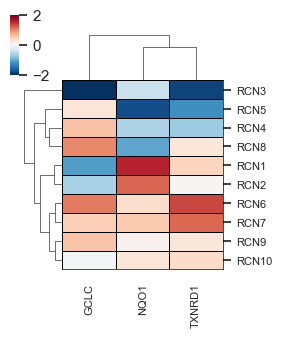

In [ ]:

markers = ['GCLC', 'NQO1', 'TXNRD1']
RCNs = ['RCN1', 'RCN2', 'RCN3', 'RCN4', 'RCN5', 'RCN6', 'RCN7', 'RCN8', 'RCN9', 'RCN10']


expression_data = []
for RCN in RCNs:
    RCN_data = data[data['RCNs'] == RCN][markers].mean()
    expression_data.append(RCN_data)

df = pd.DataFrame(expression_data, index=RCNs, columns=markers)

df_zscore = (df - df.mean()) / df.std()


plt.figure(figsize=(4, 3))
g = sns.clustermap(df_zscore, 
                  cmap='RdBu_r', 
                  center=0,   
                  vmin=-2,    
                  vmax=2,         
                  xticklabels=True,
                  yticklabels=True,
                  dendrogram_ratio=0.2,
                  cbar_pos=(0.02, 0.8, 0.03, 0.2),
                  linewidths=0.5,
                  linecolor='black',
                  square=True,
                  figsize=(3, 3)
                 )

for spine in g.ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.5)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='center', fontsize=8)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)


plt.suptitle('', y=1.02)

# Save as PDF
#plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/antiox_markers_expression_by_RCNs_all.pdf', bbox_inches='tight', dpi=500)
plt.show()

## Tumor cells

In [4]:
data_tumor = data[data['celltype_1'] == 'Tumor']

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning:

``square=True`` ignored in clustermap



<Figure size 400x300 with 0 Axes>

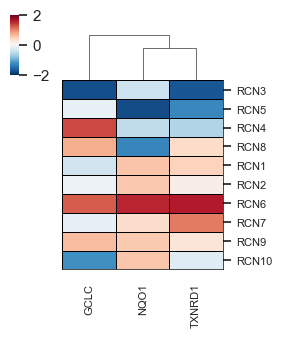

In [5]:

markers = ['GCLC', 'NQO1', 'TXNRD1']
RCNs = ['RCN3', 'RCN5', 'RCN4', 'RCN8', 'RCN1', 'RCN2', 'RCN6', 'RCN7', 'RCN9', 'RCN10']


expression_data = []
for RCN in RCNs:
    RCN_data = data_tumor[data_tumor['RCNs'] == RCN][markers].mean()
    expression_data.append(RCN_data)

df = pd.DataFrame(expression_data, index=RCNs, columns=markers)

df_zscore = (df - df.mean()) / df.std()


plt.figure(figsize=(4, 3))
g = sns.clustermap(df_zscore, 
                  cmap='RdBu_r', 
                  center=0,   
                  vmin=-2,    
                  vmax=2,         
                  xticklabels=True,
                  yticklabels=True,
                  row_cluster=False,
                  col_cluster=True,
                  dendrogram_ratio=0.2,
                  cbar_pos=(0.02, 0.8, 0.03, 0.2),
                  linewidths=0.5,
                  linecolor='black',
                  square=True,
                  figsize=(3, 3)
                 )

for spine in g.ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.5)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='center', fontsize=8)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)


plt.suptitle('', y=1.02)

# Save as PDF
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/antiox_markers_expression_by_RCNs_tumor_withoutTree.pdf', bbox_inches='tight', dpi=500)
plt.show()

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning:

``square=True`` ignored in clustermap



<Figure size 400x300 with 0 Axes>

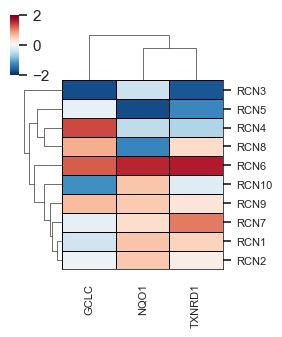

In [6]:

markers = ['GCLC', 'NQO1', 'TXNRD1']
RCNs = ['RCN1', 'RCN2', 'RCN3', 'RCN4', 'RCN5', 'RCN6', 'RCN7', 'RCN8', 'RCN9', 'RCN10']


expression_data = []
for RCN in RCNs:
    RCN_data = data_tumor[data_tumor['RCNs'] == RCN][markers].mean()
    expression_data.append(RCN_data)

df = pd.DataFrame(expression_data, index=RCNs, columns=markers)

df_zscore = (df - df.mean()) / df.std()


plt.figure(figsize=(4, 3))
g = sns.clustermap(df_zscore, 
                  cmap='RdBu_r', 
                  center=0,   
                  vmin=-2,    
                  vmax=2,         
                  xticklabels=True,
                  yticklabels=True,
                  dendrogram_ratio=0.2,
                  cbar_pos=(0.02, 0.8, 0.03, 0.2),
                  linewidths=0.5,
                  linecolor='black',
                  square=True,
                  figsize=(3, 3)
                 )

for spine in g.ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.5)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='center', fontsize=8)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)


plt.suptitle('', y=1.02)

# Save as PDF
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/antiox_markers_expression_by_RCNs_tumor.pdf', bbox_inches='tight', dpi=500)
plt.show()

# Marker expression by celltypes

In [4]:
# add one column shows celltype + annotation
data['celltype_Annotation'] = data['celltype_1'] + '_' + data['Annotation']

In [5]:
data_subset = data[['GCLC', 'NQO1', 'TXNRD1', 'celltype_1', 'Annotation', 'celltype_Annotation']]
data_subset

,GCLC,NQO1,TXNRD1,celltype_1,Annotation,celltype_Annotation
CellID,,,,,,
1,0.170813,0.133212,0.233933,Other.Stroma,Invasive border,Other.Stroma_Invasive border
10,0.288927,0.920970,0.574179,Tumor,Tumor center,Tumor_Tumor center
10,0.392473,0.527165,0.330708,CD68.Macrophages,Invasive border,CD68.Macrophages_Invasive border
100,0.278554,0.864835,0.515391,Tumor,Tumor center,Tumor_Tumor center
100,0.377826,0.444848,0.293672,Other.Immune,Invasive border,Other.Immune_Invasive border
...,...,...,...,...,...,...
99998,0.456331,0.446660,0.452719,Tumor,Inflammation,Tumor_Inflammation
99999,0.640434,0.422046,0.499728,Treg,Tumor center,Treg_Tumor center
99999,0.526600,0.421663,0.475171,CD4.T.cells,Lymph node met,CD4.T.cells_Lymph node met


In [6]:
# Create a heatmap of the expression of the markers by cell type and annotation

# Define the markers and cell type annotations
markers = ['GCLC', 'NQO1', 'TXNRD1']
celltype_Annotation = data_subset['celltype_Annotation'].unique()
# Get the mean expression of the markers for each cell type annotation
expression_data = []
for CA in celltype_Annotation:
    CA_data = data_subset[data_subset['celltype_Annotation'] == CA][markers].mean()
    expression_data.append(CA_data)
# Create a DataFrame from the expression data and calculate the z-scores
df = pd.DataFrame(expression_data, index=celltype_Annotation, columns=markers)
df_zscore = (df - df.mean()) / df.std()

## All

In [7]:
df_zscore_all = df_zscore

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_67979/516618508.py:91: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



<Figure size 800x700 with 0 Axes>

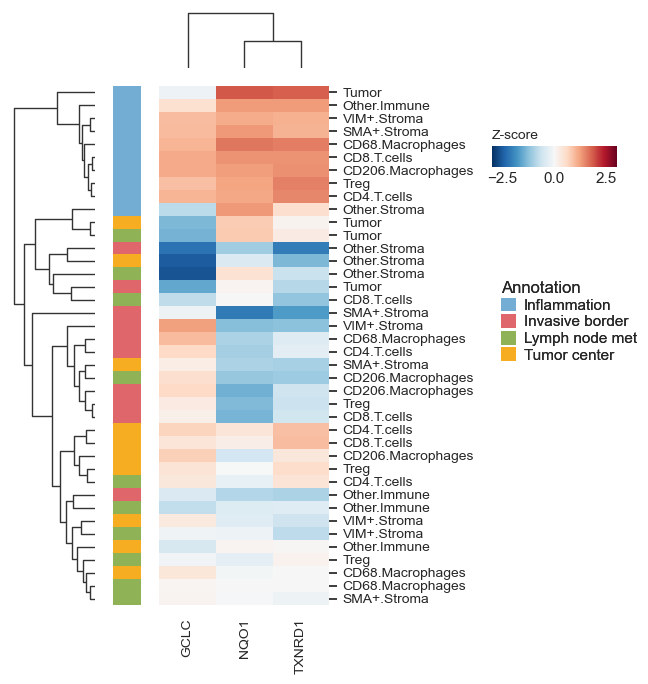

In [8]:
# Create row annotations DataFrame
row_colors = pd.DataFrame(index=celltype_Annotation)
row_colors['Annotation'] = [x.split('_')[1] for x in celltype_Annotation]
# Define color mappings
annotation_colors = {
    'Inflammation': '#73add3',    
    'Invasive border': '#df676b', 
    'Lymph node met': '#8fb257',  
    'Tumor center': '#f6ad22'     
}
# Create the color lists for each annotation
annotation_colors_list = pd.Series(row_colors['Annotation']).map(annotation_colors)


# Create the heatmap
plt.figure(figsize=(8, 7))
g = sns.clustermap(df_zscore,
                   cmap="RdBu_r",
                   center=0,
                   vmin=-3,
                   vmax=3,
                   figsize=(5, 7),
                   xticklabels=True,
                   yticklabels=True,
                   row_cluster=True,
                   col_cluster=True,
                   dendrogram_ratio=(.3, .1),
                   row_colors=[annotation_colors_list],
                   colors_ratio=0.1,
                   cbar_pos=(0.02, 0.8, 0.05, 0.18),
                   tree_kws={'linewidths': 1.0}
                   )

# Modify y-axis labels to only show the part before "_"
y_labels = [label.get_text().split('_')[0] for label in g.ax_heatmap.get_yticklabels()]
g.ax_heatmap.set_yticklabels(y_labels)
plt.subplots_adjust(right=0.7)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=10, rotation=90)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=10)
#g.ax_heatmap.tick_params(axis='x', length=0)
#g.ax_heatmap.tick_params(axis='y', length=0)

# remove the legends
if hasattr(g, 'legend_out'):
    g.legend_out.remove()
if hasattr(g, 'cax'):
    g.cax.remove()
    
    
# Add the annotations to the heatmap
legend_x = 1.0 # x location of the legend
# Add the colorbar
cbar_ax = g.fig.add_axes([legend_x, 0.75, 0.25, 0.03])  # [x, y, width, height]
cbar_ax.set_title('Z-score', fontsize=10, fontweight='normal', loc='left', pad=5)

# place the colorbar horizontally
norm = plt.Normalize(vmin=-3, vmax=3)
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
sm.set_array([])
cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.outline.set_visible(False) # remove the outline of the colorbar
cbar_ax.tick_params(size=0, labelbottom=True, labeltop=False)
cbar_ax.xaxis.set_ticks_position('bottom') 


legend_y1 = 0.6  # y location of the first legend
# Add the annotations legend
annotation_handles = [plt.Rectangle((0, 0), 0.7, 1, color=annotation_colors[label], ec="none") 
                      for label in annotation_colors.keys()]
annotation_labels = list(annotation_colors.keys())
legend = g.fig.legend(annotation_handles, annotation_labels, 
                           title='Annotation', 
                           loc='upper left',
                           bbox_to_anchor=(legend_x, 0.6),
                           frameon=False,
                           handleheight=1.0, 
                           handlelength=1.0,
                           handletextpad=0.5,
                           labelspacing=0.1,
                           borderpad=0.1,
                           markerscale=1.0)

g.fig.add_artist(legend)
legend._legend_box.align = "left"
#legend.get_title().set_fontweight('bold')



#plt.suptitle('Gene Expression Heatmap', y=0.98)
plt.tight_layout()
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/antiox_markers_expression_by_all_annotation_dpi300.pdf', bbox_inches='tight', dpi=300)
# plt.show()

## Tumor

In [15]:
df_zscore_tumor = df_zscore.loc[['Tumor_Inflammation', 'Tumor_Invasive border', 'Tumor_Lymph node met', 'Tumor_Tumor center']]
markers = ['GCLC', 'NQO1', 'TXNRD1']
celltype_Annotation = df_zscore_tumor.index
df_zscore_tumor

,GCLC,NQO1,TXNRD1
Tumor_Inflammation,-0.186585,1.865516,1.786098
Tumor_Invasive border,-1.565963,0.089258,-0.864619
Tumor_Lymph node met,-1.417073,0.790107,0.244940
Tumor_Tumor center,-1.336342,0.767053,0.100197


In [ ]:
# Create row annotations DataFrame
row_colors = pd.DataFrame(index=celltype_Annotation)
row_colors['Annotation'] = [x.split('_')[1] for x in celltype_Annotation]
# Define color mappings
annotation_colors = {
    'Inflammation': '#73add3',    
    'Invasive border': '#df676b', 
    'Lymph node met': '#8fb257',  
    'Tumor center': '#f6ad22'     
}
# Create the color lists for each annotation
annotation_colors_list = pd.Series(row_colors['Annotation']).map(annotation_colors)


# Create the heatmap
plt.figure(figsize=(8, 7))
g = sns.clustermap(df_zscore_tumor,
                   cmap="RdBu_r",
                   center=0,
                   vmin=-3,
                   vmax=3,
                   figsize=(5, 7),
                   xticklabels=True,
                   yticklabels=True,
                   row_cluster=True,
                   col_cluster=True,
                   dendrogram_ratio=(.3, .1),
                   row_colors=[annotation_colors_list],
                   colors_ratio=0.1,
                   cbar_pos=(0.02, 0.8, 0.05, 0.18),
                   tree_kws={'linewidths': 1.0}
                   )

# Modify y-axis labels to only show the part before "_"
y_labels = [label.get_text().split('_')[0] for label in g.ax_heatmap.get_yticklabels()]
g.ax_heatmap.set_yticklabels(y_labels)
plt.subplots_adjust(right=0.7)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=10, rotation=90)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=10)
#g.ax_heatmap.tick_params(axis='x', length=0)
#g.ax_heatmap.tick_params(axis='y', length=0)

# remove the legends
if hasattr(g, 'legend_out'):
    g.legend_out.remove()
if hasattr(g, 'cax'):
    g.cax.remove()
    
    
# Add the annotations to the heatmap
legend_x = 1.0 # x location of the legend
# Add the colorbar
cbar_ax = g.fig.add_axes([legend_x, 0.75, 0.25, 0.03])  # [x, y, width, height]
cbar_ax.set_title('Z-score', fontsize=10, fontweight='normal', loc='left', pad=5)

# place the colorbar horizontally
norm = plt.Normalize(vmin=-3, vmax=3)
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
sm.set_array([])
cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.outline.set_visible(False) # remove the outline of the colorbar
cbar_ax.tick_params(size=0, labelbottom=True, labeltop=False)
cbar_ax.xaxis.set_ticks_position('bottom') 


legend_y1 = 0.6  # y location of the first legend
# Add the annotations legend
annotation_handles = [plt.Rectangle((0, 0), 0.7, 1, color=annotation_colors[label], ec="none") 
                      for label in annotation_colors.keys()]
annotation_labels = list(annotation_colors.keys())
legend = g.fig.legend(annotation_handles, annotation_labels, 
                           title='Annotation', 
                           loc='upper left',
                           bbox_to_anchor=(legend_x, 0.6),
                           frameon=False,
                           handleheight=1.0, 
                           handlelength=1.0,
                           handletextpad=0.5,
                           labelspacing=0.1,
                           borderpad=0.1,
                           markerscale=1.0)

g.fig.add_artist(legend)
legend._legend_box.align = "left"
#legend.get_title().set_fontweight('bold')



#plt.suptitle('Gene Expression Heatmap', y=0.98)
plt.tight_layout()
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/antiox_markers_expression_by_tumor_annotation.pdf', bbox_inches='tight', dpi=500)
plt.show()

## Other

In [ ]:
tumor_indices = ['Tumor_Inflammation', 'Tumor_Invasive border', 'Tumor_Lymph node met', 'Tumor_Tumor center']
df_zscore_other = df_zscore[~df_zscore.index.isin(tumor_indices)]
markers = ['GCLC', 'NQO1', 'TXNRD1']
celltype_Annotation = df_zscore_other.index
df_zscore_other

In [ ]:
# Create row annotations DataFrame
row_colors = pd.DataFrame(index=celltype_Annotation)
row_colors['Annotation'] = [x.split('_')[1] for x in celltype_Annotation]
# Define color mappings
annotation_colors = {
    'Inflammation': '#73add3',    
    'Invasive border': '#df676b', 
    'Lymph node met': '#8fb257',  
    'Tumor center': '#f6ad22'     
}
# Create the color lists for each annotation
annotation_colors_list = pd.Series(row_colors['Annotation']).map(annotation_colors)


# Create the heatmap
plt.figure(figsize=(8, 7))
g = sns.clustermap(df_zscore_other,
                   cmap="RdBu_r",
                   center=0,
                   vmin=-3,
                   vmax=3,
                   figsize=(5, 7),
                   xticklabels=True,
                   yticklabels=True,
                   row_cluster=True,
                   col_cluster=True,
                   dendrogram_ratio=(.3, .1),
                   row_colors=[annotation_colors_list],
                   colors_ratio=0.1,
                   cbar_pos=(0.02, 0.8, 0.05, 0.18),
                   tree_kws={'linewidths': 1.0}
                   )

# Modify y-axis labels to only show the part before "_"
y_labels = [label.get_text().split('_')[0] for label in g.ax_heatmap.get_yticklabels()]
g.ax_heatmap.set_yticklabels(y_labels)
plt.subplots_adjust(right=0.7)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=10, rotation=90)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=10)
#g.ax_heatmap.tick_params(axis='x', length=0)
#g.ax_heatmap.tick_params(axis='y', length=0)

# remove the legends
if hasattr(g, 'legend_out'):
    g.legend_out.remove()
if hasattr(g, 'cax'):
    g.cax.remove()
    
    
# Add the annotations to the heatmap
legend_x = 1.0 # x location of the legend
# Add the colorbar
cbar_ax = g.fig.add_axes([legend_x, 0.75, 0.25, 0.03])  # [x, y, width, height]
cbar_ax.set_title('Z-score', fontsize=10, fontweight='normal', loc='left', pad=5)

# place the colorbar horizontally
norm = plt.Normalize(vmin=-3, vmax=3)
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
sm.set_array([])
cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.outline.set_visible(False) # remove the outline of the colorbar
cbar_ax.tick_params(size=0, labelbottom=True, labeltop=False)
cbar_ax.xaxis.set_ticks_position('bottom') 


legend_y1 = 0.6  # y location of the first legend
# Add the annotations legend
annotation_handles = [plt.Rectangle((0, 0), 0.7, 1, color=annotation_colors[label], ec="none") 
                      for label in annotation_colors.keys()]
annotation_labels = list(annotation_colors.keys())
legend = g.fig.legend(annotation_handles, annotation_labels, 
                           title='Annotation', 
                           loc='upper left',
                           bbox_to_anchor=(legend_x, 0.6),
                           frameon=False,
                           handleheight=1.0, 
                           handlelength=1.0,
                           handletextpad=0.5,
                           labelspacing=0.1,
                           borderpad=0.1,
                           markerscale=1.0)

g.fig.add_artist(legend)
legend._legend_box.align = "left"
#legend.get_title().set_fontweight('bold')



#plt.suptitle('Gene Expression Heatmap', y=0.98)
plt.tight_layout()
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/antiox_markers_expression_by_other_annotation.pdf', bbox_inches='tight', dpi=500)
plt.show()

# Spatial interaction

In [6]:
adata.obs

,X_centroid,Y_centroid,core_imageid,cores.x,celltype,Annotation,Stage,patient_id_AB19_1654,Area,Eccentricity,...,NQO1_GCLC_VIM,celltype_2,celltype_1,Tumor_state,GCLC_VIM,CellCategory,SC45px_neigh_kmeans_10,RCNs,CellID,imageid
19_02_02A_1,2027.642,1011.2380,core77_19_02_02A,core77,Other,Invasive border,2,AB19-1654_P10158,282,0.821700,...,---,Other,Other.Stroma,Other.Stroma,Other.Stroma,Stroma,4,RCN3,1,19_02_02A
19_02_01A_10,5871.136,777.1124,core77_19_02_01A,core77,Tumor,Tumor center,2,AB19-1654_P10117,258,0.620470,...,+--,Tumor_+--,Tumor,Tumor,Tumor.GCLC-VIM-,Tumor,2,RCN1,10,19_02_01A
19_02_02A_10,1999.424,1195.5040,core77_19_02_02A,core77,CD68.Macrophages,Invasive border,2,AB19-1654_P10158,125,0.755401,...,+--,CD68.Macrophages,CD68.Macrophages,CD68.Macrophages,CD68.Macrophages,Immune,4,RCN3,10,19_02_02A
19_02_01A_100,6136.928,858.5450,core77_19_02_01A,core77,Tumor,Tumor center,2,AB19-1654_P10117,222,0.803584,...,+--,Tumor_+--,Tumor,Tumor,Tumor.GCLC-VIM-,Tumor,2,RCN1,100,19_02_01A
19_02_02A_100,1728.540,1302.0830,core77_19_02_02A,core77,Immune,Invasive border,2,AB19-1654_P10158,300,0.522613,...,---,Immune,Other.Immune,Other.Immune,Other.Immune,Immune,4,RCN3,100,19_02_02A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INF1_99998,36889.410,6446.4120,core22_INF1,core22,Tumor,Inflammation,unknown,AB19-1654_P10648,148,0.641780,...,---,Tumor_---,Tumor,Tumor,Tumor.GCLC-VIM-,Tumor,2,RCN1,99998,INF1
1B_99999,11181.530,7239.2680,core64_1B,core64,FOXP3.CD4.Tregs,Tumor center,2,AB19-1654_P10561,366,0.771436,...,-++,FOXP3.CD4.Tregs,Treg,Treg,Treg,Immune,1,RCN2,99999,1B
2B_99999,8371.249,6579.8230,core71_2B,core71,CD4.T.cells,Lymph node met,2,AB19-1654_P10599,558,0.863484,...,-++,CD4.T.cells,CD4.T.cells,CD4.T.cells,CD4.T.cells,Immune,1,RCN2,99999,2B
3B_99999,20828.410,4477.0180,core42_3B,core42,Tumor,Tumor center,1,AB19-1654_P10620,112,0.883622,...,---,Tumor_---,Tumor,Tumor,Tumor.GCLC-VIM-,Tumor,2,RCN1,99999,3B


In [ ]:
adata = sm.tl.spatial_interaction(adata,
                                  phenotype='GCLC_VIM', 
                                  method='radius', 
                                  imageid = 'imageid',
                                  radius=45, 
                                  label='spatial_interaction_radius45_imageid')

In [22]:
adata.obs['Stage'] = adata.obs['Stage'].astype(str)

In [23]:
adata.write('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/adata_interaction_radius45_imageid.h5ad')

## Plots

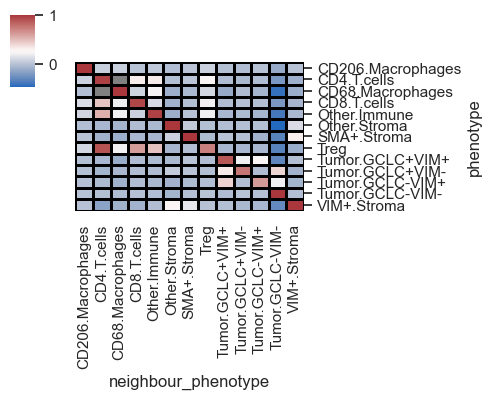

In [13]:
# view the results
sm.pl.spatial_interaction(adata, 
                          spatial_interaction='spatial_interaction_radius45_imageid',
                          linewidths=0.75, linecolor='black', figsize=(5,4))

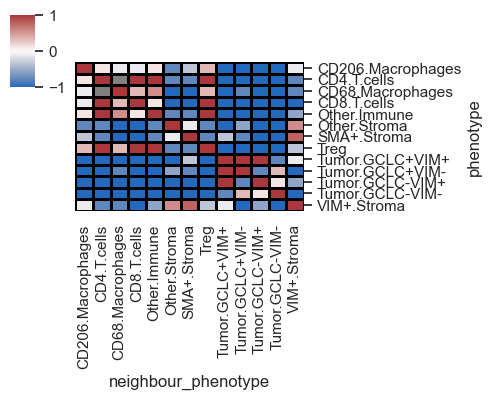

In [20]:
sm.pl.spatial_interaction(adata, 
                          spatial_interaction='spatial_interaction_radius45_imageid',  binary_view=True,
                          linewidths=0.75, linecolor='black', figsize=(5,4))

In [ ]:
sm.pl.spatial_interaction(adata, 
                          spatial_interaction='spatial_interaction_radius45_imageid',
                          yticklabels=True, figsize=(7,27), row_cluster=True,
                          summarize_plot=False,
                          linewidths=0.75, linecolor='black')

In [ ]:
sm.pl.spatialInteractionNetwork(adata, spatial_interaction='spatial_interaction_radius45_imageid', figsize=(6,4))

In [11]:
adata

AnnData object with n_obs × n_vars = 3681772 × 25
    obs: 'X_centroid', 'Y_centroid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage', 'patient_id_AB19_1654', 'Area', 'Eccentricity', 'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1', 'NQO1_GCLC_VIM', 'celltype_2', 'celltype_1', 'Tumor_state', 'GCLC_VIM', 'CellCategory', 'SC45px_neigh_kmeans_10', 'RCNs', 'CellID', 'imageid'
    uns: 'all_markers', 'spatial_interaction_radius45_imageid'
    obsm: 'spatial'

In [12]:
adata.uns['spatial_interaction_radius45_imageid']

,phenotype,neighbour_phenotype,19_02_02A,pvalue_19_02_02A,19_02_01A,pvalue_19_02_01A,T2,pvalue_T2,INF2,pvalue_INF2,19_02_03A,pvalue_19_02_03A,1B,pvalue_1B,2B,pvalue_2B,3B,pvalue_3B,INF1,pvalue_INF1
0,CD206.Macrophages,CD206.Macrophages,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000e+00
1,CD206.Macrophages,CD4.T.cells,0.150976,1.300783e-34,0.190766,0.000000e+00,-0.239333,0.000000e+00,0.372996,5.680282e-202,0.150778,0.000000,0.242094,0.000000e+00,-0.233469,4.536373e-13,-0.088370,2.909132e-04,-0.094998,0.000000e+00
2,CD206.Macrophages,CD68.Macrophages,-0.043375,0.000000e+00,-0.074229,2.465351e-01,-0.149120,1.658592e-186,0.225893,3.652303e-77,0.655337,0.000000,0.085235,1.386576e-02,0.154522,1.745754e-02,-0.126482,0.000000e+00,-0.246316,4.452572e-02
3,CD206.Macrophages,CD8.T.cells,0.070852,0.000000e+00,0.128785,0.000000e+00,-0.048673,5.266268e-46,0.179284,6.138952e-269,0.233650,0.000000,-0.130269,0.000000e+00,-0.167564,0.000000e+00,-0.117421,3.759444e-116,-0.167422,0.000000e+00
4,CD206.Macrophages,Other.Immune,0.097836,5.805508e-147,0.165594,0.000000e+00,-0.059119,2.944598e-97,-0.393672,2.805071e-60,0.196582,0.000000,0.055356,1.321300e-04,0.294446,0.000000e+00,-0.087111,0.000000e+00,-0.096968,1.927466e-106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,VIM+.Stroma,Tumor.GCLC+VIM+,-0.319783,0.000000e+00,0.158298,0.000000e+00,0.072336,3.669308e-240,0.180598,2.882561e-81,0.157854,0.000000,-0.194540,9.235705e-207,-0.078109,8.932934e-10,-0.071216,2.902172e-223,-0.096877,2.366937e-306
165,VIM+.Stroma,Tumor.GCLC+VIM-,-0.042224,0.000000e+00,-0.037861,3.810942e-145,-0.039764,0.000000e+00,-0.111098,1.764734e-13,-0.257130,0.000000,-0.003391,8.097413e-26,-0.001397,4.096793e-61,-0.002015,3.690981e-250,-0.002262,8.976581e-67
166,VIM+.Stroma,Tumor.GCLC-VIM+,-0.039704,8.669859e-03,-0.012495,3.467208e-05,0.011444,5.251644e-34,0.030067,3.241833e-04,-0.000640,0.000002,-0.187695,0.000000e+00,-0.108649,4.695885e-297,-0.140079,0.000000e+00,-0.108224,0.000000e+00
167,VIM+.Stroma,Tumor.GCLC-VIM-,-0.219016,0.000000e+00,-0.407157,0.000000e+00,-0.298764,0.000000e+00,-0.363030,0.000000e+00,-0.639414,0.000000,-0.227382,0.000000e+00,-0.250778,0.000000e+00,-0.120387,0.000000e+00,-0.221877,0.000000e+00
